# notebooks/evaluation_results.ipynp
### **Comparison notebook** to visualise the lift between Week 10's (The Conversion Engine) baseline and the new Judge model.
### This notebook will pull metrics from both `eval_baseline.py`, `eval_judge.py` and `eval_prompted_judge.py`.
### Compare Baseline vs Judge model Vs Prompted Judge metrics

## 1. Setup

In [4]:
from pathlib import Path
import json
import math
import random

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
REPORTS = ROOT / "reports/evaluation"
REPORTS.mkdir(exist_ok=True)

METRIC_FILES = {
    "Week 10 Baseline": REPORTS / "baseline/baseline_metrics.json",
    "Prompted Judge": REPORTS / "prompted/prompted_judge_metrics.json",
    "Fine-Tuned DPO Judge": REPORTS / "fine_tuned/fine_tuned_judge_metrics.json",
}

PAIR_SCORE_FILES = {
    "Week 10 Baseline": REPORTS / "baseline/baseline_pair_scores.jsonl",
    "Prompted Judge": REPORTS / "prompted/prompted_judge_pair_scores.jsonl",
    "Fine-Tuned DPO Judge": REPORTS / "fine_tuned/fine_tuned_judge_pair_scores.jsonl",
}

for label, path in METRIC_FILES.items():
    assert path.exists(), f"Missing metric file for {label}: {path}"

print("All metric files found.")

All metric files found.


## 2. Load metrics

In [5]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

metrics_raw = {label: load_json(path) for label, path in METRIC_FILES.items()}

core_metrics = ["accuracy", "precision", "recall", "f1"]

rows = []
for model_name, metrics in metrics_raw.items():
    row = {"model": model_name}
    for metric in core_metrics:
        row[metric] = metrics.get(metric)
    row["pairwise_accuracy"] = metrics.get("pairwise_accuracy")
    row["strict_pairwise_accuracy"] = metrics.get("strict_pairwise_accuracy", metrics.get("pairwise_accuracy"))
    row["num_pairs"] = metrics.get("num_pairs")
    row["num_pointwise_examples"] = metrics.get("num_pointwise_examples")
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df

,model,accuracy,precision,recall,f1,pairwise_accuracy,strict_pairwise_accuracy,num_pairs,num_pointwise_examples
0,Week 10 Baseline,0.807692,0.944444,0.653846,0.772727,0.615385,0.615385,26,52
1,Prompted Judge,0.884615,1.000000,0.769231,0.869565,1.000000,0.769231,26,52
2,Fine-Tuned DPO Judge,0.961538,0.961538,0.961538,0.961538,0.961538,0.961538,26,52


## 3. Save comparison table

In [6]:
comparison_csv = REPORTS / "evaluation_metric_comparison.csv"
comparison_json = REPORTS / "evaluation_metric_comparison.json"

comparison_df.to_csv(comparison_csv, index=False)
comparison_df.to_json(comparison_json, orient="records", indent=2)

print(f"Saved: {comparison_csv}")
print(f"Saved: {comparison_json}")
comparison_df

Saved: ..\reports\evaluation\evaluation_metric_comparison.csv
Saved: ..\reports\evaluation\evaluation_metric_comparison.json


,model,accuracy,precision,recall,f1,pairwise_accuracy,strict_pairwise_accuracy,num_pairs,num_pointwise_examples
0,Week 10 Baseline,0.807692,0.944444,0.653846,0.772727,0.615385,0.615385,26,52
1,Prompted Judge,0.884615,1.000000,0.769231,0.869565,1.000000,0.769231,26,52
2,Fine-Tuned DPO Judge,0.961538,0.961538,0.961538,0.961538,0.961538,0.961538,26,52


## 4. Pointwise metric chart

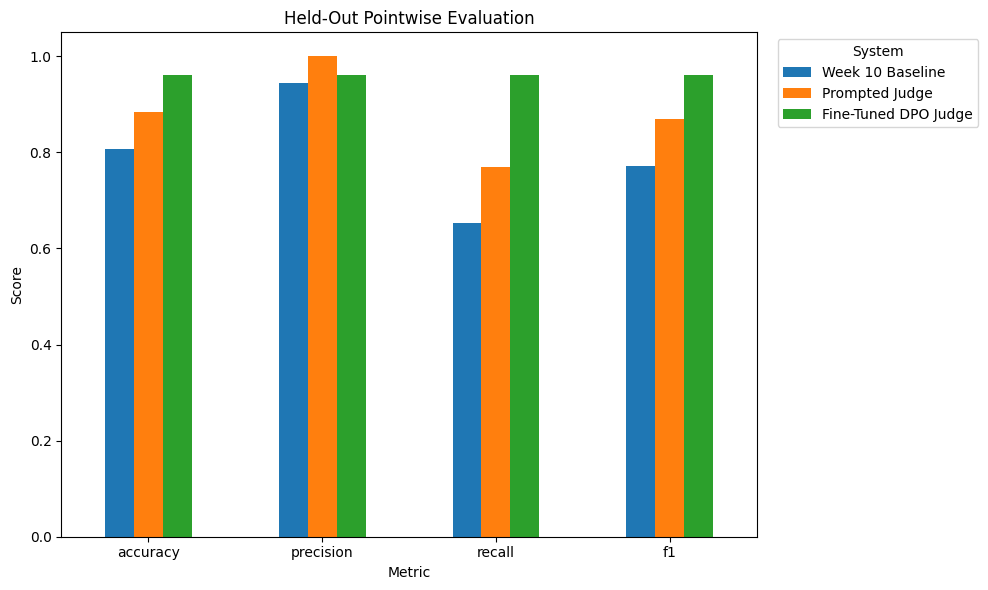

Saved: ..\reports\evaluation\ablation_comparison_chart.png


In [7]:
plot_df = comparison_df.set_index("model")[core_metrics].T

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Held-Out Pointwise Evaluation")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Metric")
ax.legend(title="System", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()

chart_path = REPORTS / "ablation_comparison_chart.png"
plt.savefig(chart_path, dpi=160)
plt.show()

print(f"Saved: {chart_path}")

## 5. Pairwise / deployment-gate chart

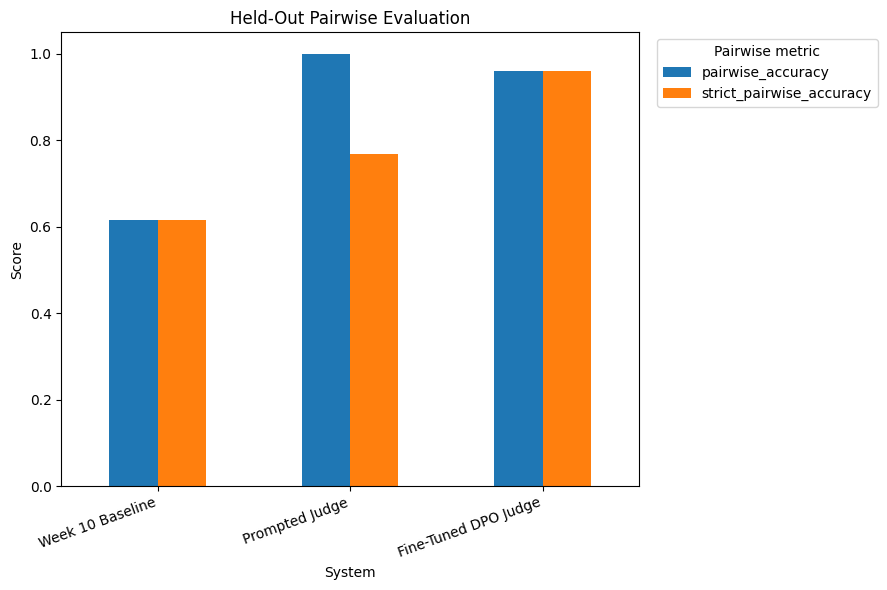

Saved: ..\reports\evaluation\pairwise_ablation_chart.png


In [8]:
pairwise_metrics = ["pairwise_accuracy", "strict_pairwise_accuracy"]

pair_df = comparison_df[["model"] + pairwise_metrics].copy()
pair_df = pair_df.set_index("model")

ax = pair_df.plot(kind="bar", figsize=(9, 6))
ax.set_title("Held-Out Pairwise Evaluation")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xlabel("System")
ax.legend(title="Pairwise metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

pairwise_chart = REPORTS / "pairwise_ablation_chart.png"
plt.savefig(pairwise_chart, dpi=160)
plt.show()

print(f"Saved: {pairwise_chart}")

## 6. Cell Load pair scores and paired bootstrap

In [9]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

pair_scores = {
    label: load_jsonl(path)
    for label, path in PAIR_SCORE_FILES.items()
    if path.exists()
}

def pair_correct_map(model_name, rows):
    out = {}
    for row in rows:
        pair_id = row.get("pair_id")
        if not pair_id:
            continue

        if model_name == "Week 10 Baseline":
            correct = bool(row.get("correct"))
        elif model_name == "Fine-Tuned DPO Judge":
            correct = bool(row.get("chosen_preferred"))
        elif model_name == "Prompted Judge":
            # Strict/deployment interpretation:
            # chosen must be accepted and rejected must be rejected.
            correct = bool(row.get("strict_correct"))
        else:
            correct = bool(row.get("correct"))

        out[pair_id] = int(correct)
    return out

correct_maps = {
    model_name: pair_correct_map(model_name, rows)
    for model_name, rows in pair_scores.items()
}

def paired_bootstrap_diff(model_a, model_b, n_boot=10000, seed=42):
    """
    Computes bootstrap CI for accuracy(model_a) - accuracy(model_b)
    over matched pair_ids.
    """
    rng = random.Random(seed)

    a_map = correct_maps[model_a]
    b_map = correct_maps[model_b]

    pair_ids = sorted(set(a_map) & set(b_map))
    assert pair_ids, f"No overlapping pair_ids for {model_a} and {model_b}"

    diffs = []
    for _ in range(n_boot):
        sample_ids = [rng.choice(pair_ids) for _ in pair_ids]
        a_acc = sum(a_map[p] for p in sample_ids) / len(sample_ids)
        b_acc = sum(b_map[p] for p in sample_ids) / len(sample_ids)
        diffs.append(a_acc - b_acc)

    diffs = sorted(diffs)
    lower = diffs[int(0.025 * n_boot)]
    upper = diffs[int(0.975 * n_boot)]
    observed = (
        sum(a_map[p] for p in pair_ids) / len(pair_ids)
        - sum(b_map[p] for p in pair_ids) / len(pair_ids)
    )

    # One-sided bootstrap p-value for "model_a is not better than model_b".
    p_value = sum(1 for d in diffs if d <= 0) / n_boot

    return {
        "model_a": model_a,
        "model_b": model_b,
        "metric": "strict_pairwise_accuracy",
        "num_pairs": len(pair_ids),
        "observed_delta": observed,
        "ci_95": [lower, upper],
        "one_sided_p_value_delta_lte_0": p_value,
        "positive_with_ci": lower > 0,
    }

delta_a = paired_bootstrap_diff("Fine-Tuned DPO Judge", "Week 10 Baseline")
delta_b = paired_bootstrap_diff("Fine-Tuned DPO Judge", "Prompted Judge")

pd.DataFrame([delta_a, delta_b])

,model_a,model_b,metric,num_pairs,observed_delta,ci_95,one_sided_p_value_delta_lte_0,positive_with_ci
0,Fine-Tuned DPO Judge,Week 10 Baseline,strict_pairwise_accuracy,26,0.346154,"[0.15384615384615385, 0.5384615384615385]",0.0013,True
1,Fine-Tuned DPO Judge,Prompted Judge,strict_pairwise_accuracy,26,0.192308,"[0.03846153846153855, 0.34615384615384615]",0.0039,True


## 7. Write `ablation_results.json`

In [10]:
ablation_results = {
    "summary": {
        "task": "Week 11 Path B held-out ablation comparison",
        "held_out_pointwise_examples": int(comparison_df["num_pointwise_examples"].dropna().max()),
        "held_out_pairs": int(comparison_df["num_pairs"].dropna().max()),
        "primary_metric": "strict_pairwise_accuracy",
        "note": (
            "For the prompted judge, pairwise_accuracy is rank-based, while "
            "strict_pairwise_accuracy is the deployment-style gate metric."
        ),
    },
    "systems": metrics_raw,
    "delta_a_fine_tuned_vs_baseline": delta_a,
    "delta_b_fine_tuned_vs_prompted": delta_b,
}

ablation_path = REPORTS / "ablation_results.json"
with open(ablation_path, "w", encoding="utf-8") as f:
    json.dump(ablation_results, f, indent=2, ensure_ascii=False)

print(f"Saved: {ablation_path}")

Saved: ..\reports\evaluation\ablation_results.json


## 8. Write combined raw trace file

In [11]:
held_out_traces_path = REPORTS / "held_out_traces.jsonl"

with open(held_out_traces_path, "w", encoding="utf-8") as f:
    for system_name, rows in pair_scores.items():
        for row in rows:
            out = {
                "system": system_name,
                **row,
            }
            f.write(json.dumps(out, ensure_ascii=False) + "\n")

print(f"Saved: {held_out_traces_path}")

Saved: ..\reports\evaluation\held_out_traces.jsonl


## 9. Final interpretation text

In [12]:
baseline = metrics_raw["Week 10 Baseline"]
prompted = metrics_raw["Prompted Judge"]
tuned = metrics_raw["Fine-Tuned DPO Judge"]

print("Evaluation Summary")
print("=" * 80)
print(f"Baseline accuracy:      {baseline['accuracy']:.4f}")
print(f"Prompted judge accuracy:{prompted['accuracy']:.4f}")
print(f"Fine-tuned accuracy:    {tuned['accuracy']:.4f}")
print()
print(f"Delta A accuracy lift:  {tuned['accuracy'] - baseline['accuracy']:.4f}")
print(f"Delta B accuracy lift:  {tuned['accuracy'] - prompted['accuracy']:.4f}")
print()
print(f"Baseline F1:            {baseline['f1']:.4f}")
print(f"Prompted judge F1:      {prompted['f1']:.4f}")
print(f"Fine-tuned F1:          {tuned['f1']:.4f}")
print()
print("Paired bootstrap")
print(delta_a)
print(delta_b)

Evaluation Summary
Baseline accuracy:      0.8077
Prompted judge accuracy:0.8846
Fine-tuned accuracy:    0.9615

Delta A accuracy lift:  0.1538
Delta B accuracy lift:  0.0769

Baseline F1:            0.7727
Prompted judge F1:      0.8696
Fine-tuned F1:          0.9615

Paired bootstrap
{'model_a': 'Fine-Tuned DPO Judge', 'model_b': 'Week 10 Baseline', 'metric': 'strict_pairwise_accuracy', 'num_pairs': 26, 'observed_delta': 0.34615384615384615, 'ci_95': [0.15384615384615385, 0.5384615384615385], 'one_sided_p_value_delta_lte_0': 0.0013, 'positive_with_ci': True}
{'model_a': 'Fine-Tuned DPO Judge', 'model_b': 'Prompted Judge', 'metric': 'strict_pairwise_accuracy', 'num_pairs': 26, 'observed_delta': 0.1923076923076923, 'ci_95': [0.03846153846153855, 0.34615384615384615], 'one_sided_p_value_delta_lte_0': 0.0039, 'positive_with_ci': True}
